In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoLars
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [40]:
df = pd.read_csv("antenna.csv")
df.head()

,Wm,W0m,dm,tm,rows,Xa,Ya,gain,vswr,bandwidth,s,pr,p0
0,2142.9,162.86,77.143,214.29,3.0,0.0,2142.9,2.799175,1.372040,110.6698,-16.090654,0.204248,0.483952
1,2142.9,162.86,77.143,214.29,3.0,3543.5,6964.3,2.817305,1.638103,120.7497,-12.328015,0.197374,0.464289
2,2142.9,162.86,351.430,214.29,5.0,8365.0,6964.3,2.941413,1.242714,123.6901,-19.313586,0.212885,0.490808
3,2142.9,162.86,351.430,214.29,3.0,8365.0,2142.9,2.844078,1.242587,122.4301,-19.317644,0.212405,0.496603
4,2142.9,162.86,351.430,214.29,3.0,8365.0,6964.3,2.812315,1.271176,124.3198,-18.459992,0.207997,0.489240


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Wm         572 non-null    float64
 1   W0m        572 non-null    float64
 2   dm         572 non-null    float64
 3   tm         572 non-null    float64
 4   rows       572 non-null    float64
 5   Xa         572 non-null    float64
 6   Ya         572 non-null    float64
 7   gain       572 non-null    float64
 8   vswr       572 non-null    float64
 9   bandwidth  509 non-null    float64
 10  s          572 non-null    float64
 11  pr         572 non-null    float64
 12  p0         572 non-null    float64
dtypes: float64(13)
memory usage: 58.2 KB


In [42]:
df.describe()

,Wm,W0m,dm,tm,rows,Xa,Ya,gain,vswr,bandwidth,s,pr,p0
count,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,509.000000,572.000000,572.000000,572.000000
mean,2244.048252,400.594178,275.425776,224.404825,4.097902,4063.246329,6947.469755,2.678568,2.094927,118.036075,-16.104948,0.192872,0.456955
std,691.578895,184.905214,150.901130,69.157890,1.443942,3287.862064,5136.193313,0.683242,1.914750,11.553491,7.897142,0.046994,0.089213
min,2142.900000,162.860000,77.143000,214.290000,3.000000,0.000000,2142.900000,-5.654378,1.041183,32.759900,-33.903172,0.037383,0.186297
25%,2142.900000,162.860000,77.143000,214.290000,3.000000,1132.800000,2142.900000,2.815006,1.187911,119.490100,-21.321550,0.200121,0.470947
50%,2142.900000,325.710000,214.290000,214.290000,3.000000,3543.500000,6964.300000,2.876220,1.438023,122.220100,-14.910812,0.211927,0.490360
75%,2142.900000,488.570000,351.430000,214.290000,5.000000,5954.300000,11786.000000,2.921877,1.725260,123.269800,-11.498286,0.214335,0.497100
max,6964.300000,651.430000,488.570000,696.430000,7.000000,10776.000000,16607.000000,3.238539,8.377999,124.740100,-2.083432,0.229538,0.499826


In [43]:
df.isnull().sum()

Wm            0
W0m           0
dm            0
tm            0
rows          0
Xa            0
Ya            0
gain          0
vswr          0
bandwidth    63
s             0
pr            0
p0            0
dtype: int64

In [44]:
df = df.dropna()

### Matriz de correlación
De la matriz de correlación se puede observar las diferentes relaciones (directa (+) o negativa (-)) involucrando cada variable con el resto de variables, siendo para este caso que para eliminar las variables como no relevantes se tomaron aquellas con una correlacion menor al 5% para cada variable de salida, debido a que existen casos en los cuales una variable de salida tiene una baja correlación con una variable de entrada, sin embargo otra variable de salida cuenta con una alta correlación con otra variable de entrada.

Es así que bajo este criterio se escogieron las siguientes variables de entrada para ser aliminadas **aunque se recomienda, según este dataset el uso de todos los parámetros debido a que cada valor influye en el comportamiento de la antena**

#### Entradas eliminada
1. W0m
1. tm

#### Salidas
1. dm
1. rows
1. Ya



Text(0.5, 1.0, 'Matriz de correlación')

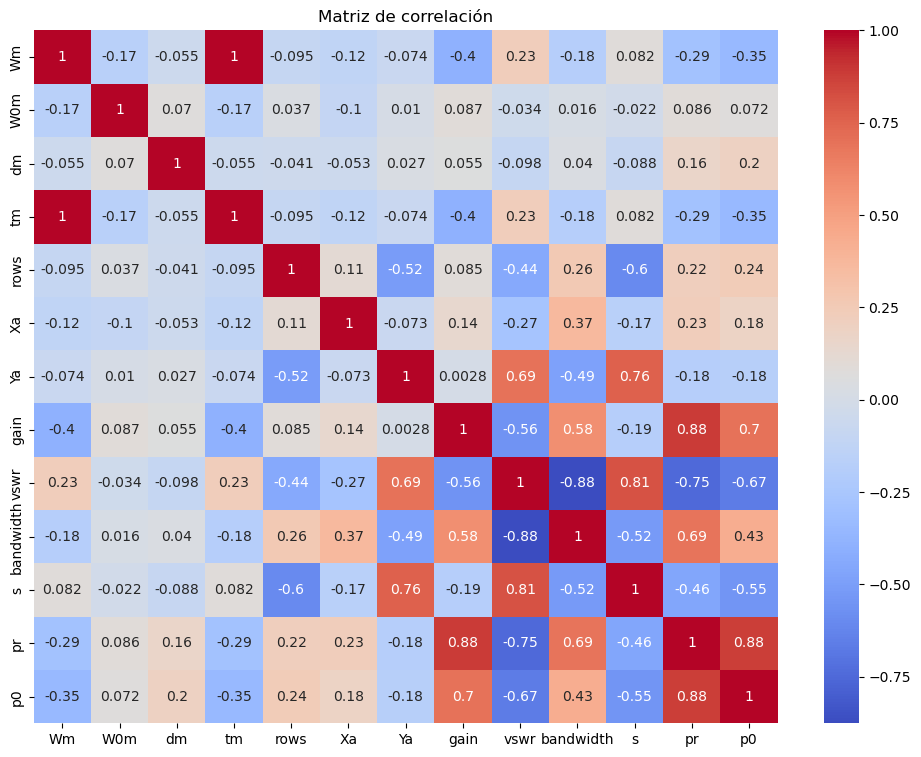

In [45]:
# Matriz de correlación
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")

In [46]:
df = df.drop(columns=["W0m", "tm"])

In [47]:
# Definir las variables de entrada y salida

X = df.drop(columns=["dm", "rows", "Ya"])
y = df[["dm", "rows", "Ya"]]
df

,Wm,dm,rows,Xa,Ya,gain,vswr,bandwidth,s,pr,p0
0,2142.9,77.143,3.0,0.0,2142.9,2.799175,1.372040,110.6698,-16.090654,0.204248,0.483952
1,2142.9,77.143,3.0,3543.5,6964.3,2.817305,1.638103,120.7497,-12.328015,0.197374,0.464289
2,2142.9,351.430,5.0,8365.0,6964.3,2.941413,1.242714,123.6901,-19.313586,0.212885,0.490808
3,2142.9,351.430,3.0,8365.0,2142.9,2.844078,1.242587,122.4301,-19.317644,0.212405,0.496603
4,2142.9,351.430,3.0,8365.0,6964.3,2.812315,1.271176,124.3198,-18.459992,0.207997,0.489240
...,...,...,...,...,...,...,...,...,...,...,...
567,2142.9,351.430,3.0,3543.5,11786.0,2.909890,1.446029,123.4801,-14.781972,0.211051,0.487707
568,2142.9,351.430,3.0,3543.5,16607.0,2.846588,1.901528,106.0500,-10.152948,0.209622,0.492615
569,2142.9,351.430,3.0,5954.3,2142.9,2.848330,1.234262,122.4298,-19.588648,0.212735,0.496863
570,2142.9,351.430,3.0,5954.3,6964.3,2.814091,1.278842,124.3200,-18.247128,0.207910,0.488803


In [48]:
# Escalamiento de valores
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Valor min después de la estandarización: {X_scaled.min()}")
print(f"Valor min después de la estandarización: {X_scaled.max()}")

Valor min después de la estandarización: -15.610769758913948
Valor min después de la estandarización: 7.674589337039452


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [50]:
models ={
    "Linear Regression" : LinearRegression(),
    "LassoLars" : LassoLars(),
    "KNeightbors" : KNeighborsRegressor(),
    "DecisitionTree" : DecisionTreeRegressor(),
    "RandomForest" : RandomForestRegressor()
}

Linear Regression - MAE : 670.1715, MSE : 2259951.2995, R2 : 0.3720


IndexError: list index out of range

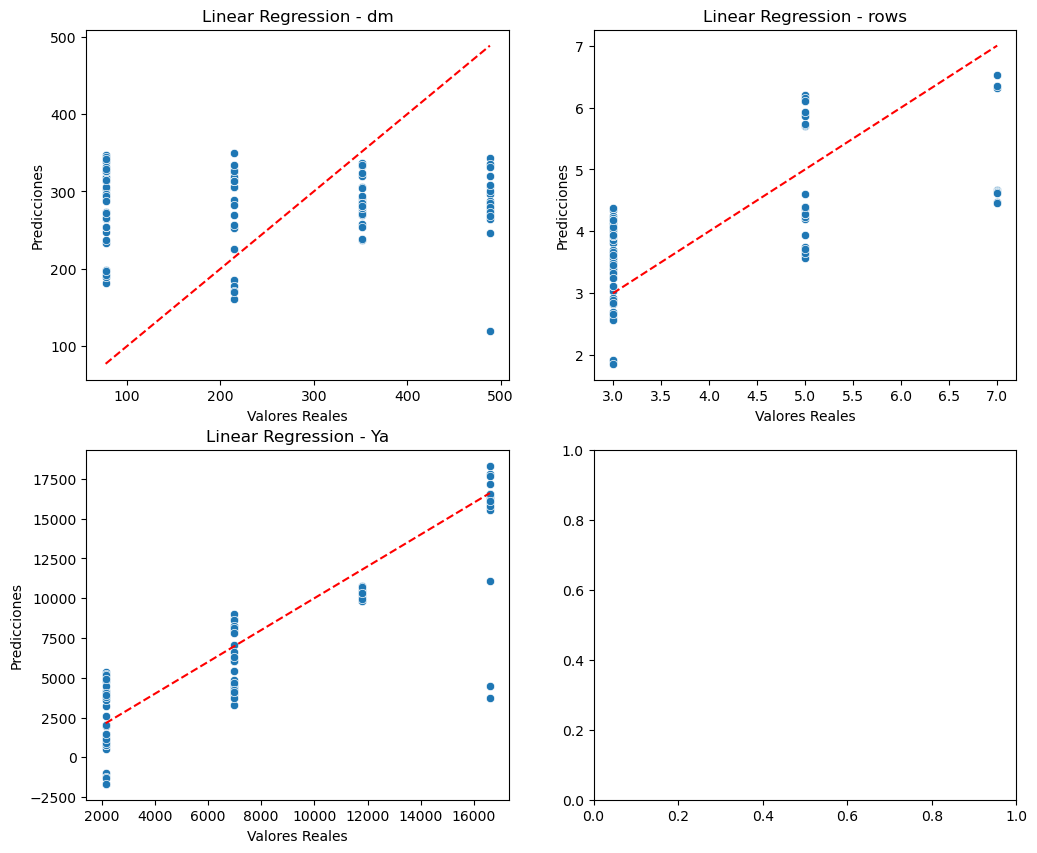

In [ ]:
results = {}

for name, model in models.items() :
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE" : mae, "MSE" : mse, "R2" : r2}
    print(f"{name} - MAE : {mae:.4f}, MSE : {mse:.4f}, R2 : {r2:.4f}")

    # Graficar predicciones vs valores reales
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    columns = ["dm", "rows", "Ya"]

    for i, ax in enumerate(axes.flat) :
        sns.scatterplot(x=y_test[columns[i]], y=y_pred[:, i], ax=ax)
        ax.set_xlabel("Valores Reales")
        ax.set_ylabel("Predicciones")
        ax.set_title(f"{name} - {columns[i]}")
        ax.plot( [min(y_test[columns[i]]), max(y_test[columns[i]])],
                 [min(y_test[columns[i]]), max(y_test[columns[i]])],
                 linestyle='--', color='red')

    plt.tight_layout()


### Resultados
De los modelos entrenados se puede destacar:
* DecisitionTree - MAE : 89.4941, MSE : 615185.7341, R2 : 0.6350
Por su bajo error y alto accuracy en comparación al resto

In [52]:
# Despliegue y monitoreo
joblib.dump(models["DecisitionTree"], "antena_model.pkl")
print("Modelo DecisionTree guardado como 'antena_model.pkl")

Modelo DecisionTree guardado como 'antena_model.pkl


In [53]:
model = joblib.load("antena_model.pkl")
model

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [54]:
df

,Wm,dm,rows,Xa,Ya,gain,vswr,bandwidth,s,pr,p0
0,2142.9,77.143,3.0,0.0,2142.9,2.799175,1.372040,110.6698,-16.090654,0.204248,0.483952
1,2142.9,77.143,3.0,3543.5,6964.3,2.817305,1.638103,120.7497,-12.328015,0.197374,0.464289
2,2142.9,351.430,5.0,8365.0,6964.3,2.941413,1.242714,123.6901,-19.313586,0.212885,0.490808
3,2142.9,351.430,3.0,8365.0,2142.9,2.844078,1.242587,122.4301,-19.317644,0.212405,0.496603
4,2142.9,351.430,3.0,8365.0,6964.3,2.812315,1.271176,124.3198,-18.459992,0.207997,0.489240
...,...,...,...,...,...,...,...,...,...,...,...
567,2142.9,351.430,3.0,3543.5,11786.0,2.909890,1.446029,123.4801,-14.781972,0.211051,0.487707
568,2142.9,351.430,3.0,3543.5,16607.0,2.846588,1.901528,106.0500,-10.152948,0.209622,0.492615
569,2142.9,351.430,3.0,5954.3,2142.9,2.848330,1.234262,122.4298,-19.588648,0.212735,0.496863
570,2142.9,351.430,3.0,5954.3,6964.3,2.814091,1.278842,124.3200,-18.247128,0.207910,0.488803


In [58]:
datos = np.array([[2139.5, 8345.40, 2.8315, 1.2788, 123.334, -31.756, 0.2267, 0.2123,]])

In [59]:
# Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(datos)

### Resultados

In [60]:
pred = model.predict(X_scaled)
pred

array([[3.5143e+02, 3.0000e+00, 1.1786e+04]])